In [70]:
from PIL.ImageShow import show

COAD_PATH = "/home/maro/final-projects/DSAI_305_XAI/data/raw/coad_tmb.parquet"
STAD_PATH = "/home/maro/final-projects/DSAI_305_XAI/data/raw/stad_tmb.parquet"

In [71]:
import pandas as pd

coad_df = pd.read_parquet(COAD_PATH).drop_duplicates(subset=["PATIENT_ID"]).set_index("PATIENT_ID")
stad_df = pd.read_parquet(STAD_PATH).drop_duplicates(subset=["PATIENT_ID"]).set_index("PATIENT_ID")

stad_df = stad_df[stad_df["TMB_NONSYNONYMOUS"] > 0].dropna(subset=["TMB_NONSYNONYMOUS"])
coad_df = coad_df[coad_df["TMB_NONSYNONYMOUS"] > 0].dropna(subset=["TMB_NONSYNONYMOUS"])

In [72]:
stad_df.describe()

,TMB_NONSYNONYMOUS
count,435.000000
mean,12.720613
std,26.450275
min,0.066667
25%,2.433333
50%,3.900000
75%,8.516667
max,330.800000


In [73]:
coad_df.describe()

,TMB_NONSYNONYMOUS
count,427.000000
mean,14.285792
std,37.617279
min,0.266667
25%,2.266667
50%,3.166667
75%,4.716667
max,433.233333


In [74]:
coad_df["Cohort"] = "COAD"
stad_df["Cohort"] = "STAD"

coad_df["TMB_Label"] = coad_df["TMB_NONSYNONYMOUS"].apply(lambda x: "High" if x > 10 else "Low")
stad_df["TMB_Label"] = stad_df["TMB_NONSYNONYMOUS"].apply(lambda x: "High" if x > 10 else "Low")

combined_df = pd.concat([coad_df, stad_df], ignore_index=True)

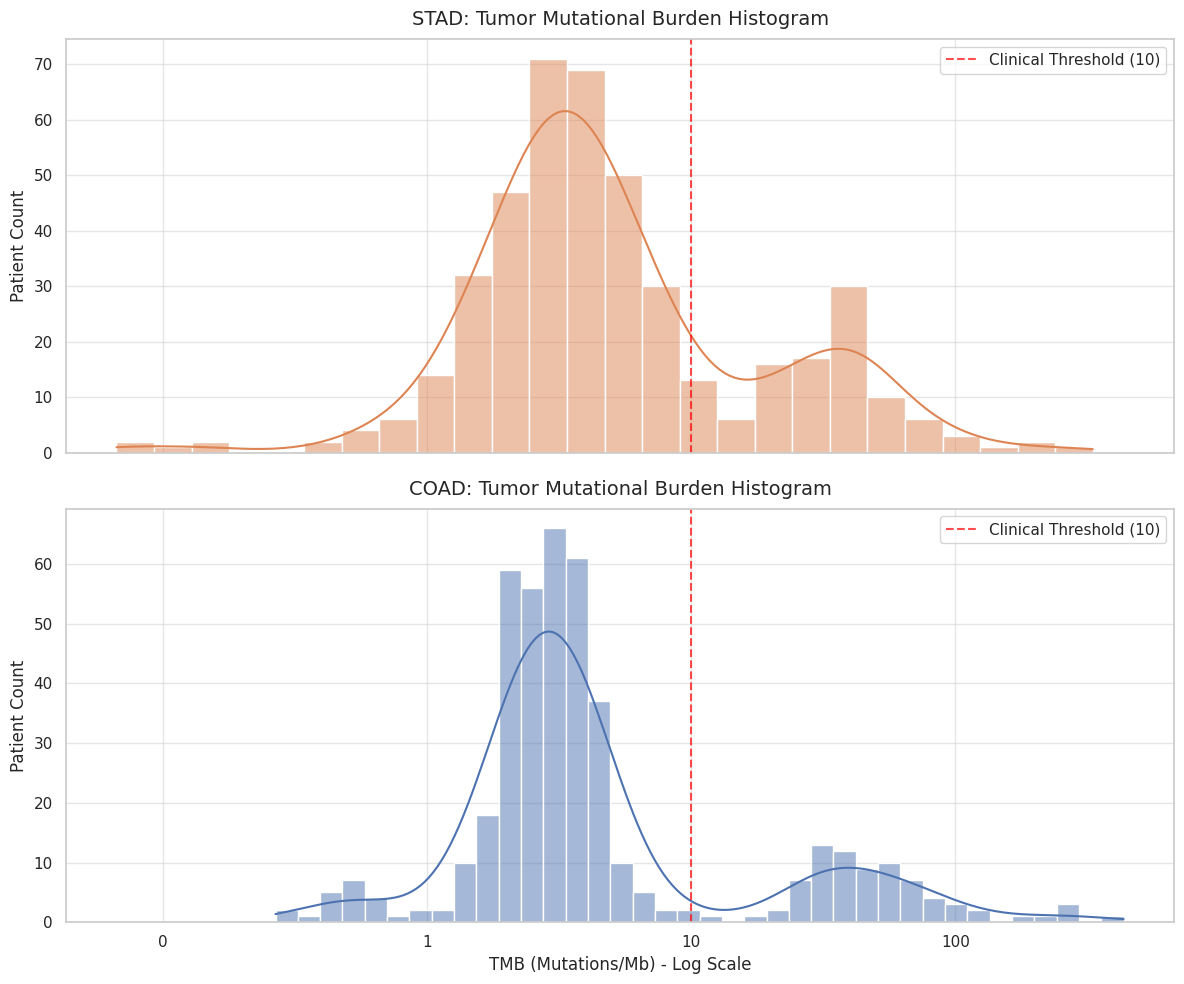

In [75]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

# Set up the canvas: 2 rows, 1 column.
# sharex=True perfectly aligns the x-axes of both plots so they match exactly.
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# =====================================================================
# TOP PLOT: STAD Histogram
# =====================================================================
sns.histplot(
    data=stad_df,
    x="TMB_NONSYNONYMOUS",
    color="#dd8452",   # Seaborn's default muted orange
    kde=True,          # Adds a smooth density curve over the bars
    log_scale=True,    # Crucial: calculates bins correctly for log-scale
    ax=axes[0]
)

axes[0].set_title("STAD: Tumor Mutational Burden Histogram", fontsize=14, pad=10)
axes[0].set_ylabel("Patient Count", fontsize=12)

# =====================================================================
# BOTTOM PLOT: COAD Histogram
# =====================================================================
sns.histplot(
    data=coad_df,
    x="TMB_NONSYNONYMOUS",
    color="#4c72b0",   # Seaborn's default muted blue
    kde=True,
    log_scale=True,
    ax=axes[1]
)

axes[1].set_title("COAD: Tumor Mutational Burden Histogram", fontsize=14, pad=10)
axes[1].set_ylabel("Patient Count", fontsize=12)
axes[1].set_xlabel("TMB (Mutations/Mb) - Log Scale", fontsize=12)

# =====================================================================
# FORMATTING & AESTHETICS
# =====================================================================
for ax in axes:
    # Add the vertical FDA threshold line (TMB = 10)
    ax.axvline(10, color='red', linestyle='--', alpha=0.7, label='Clinical Threshold (10)')

    # Fix the x-axis ticks so they show as 1, 10, 100 instead of 10^0, 10^1
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

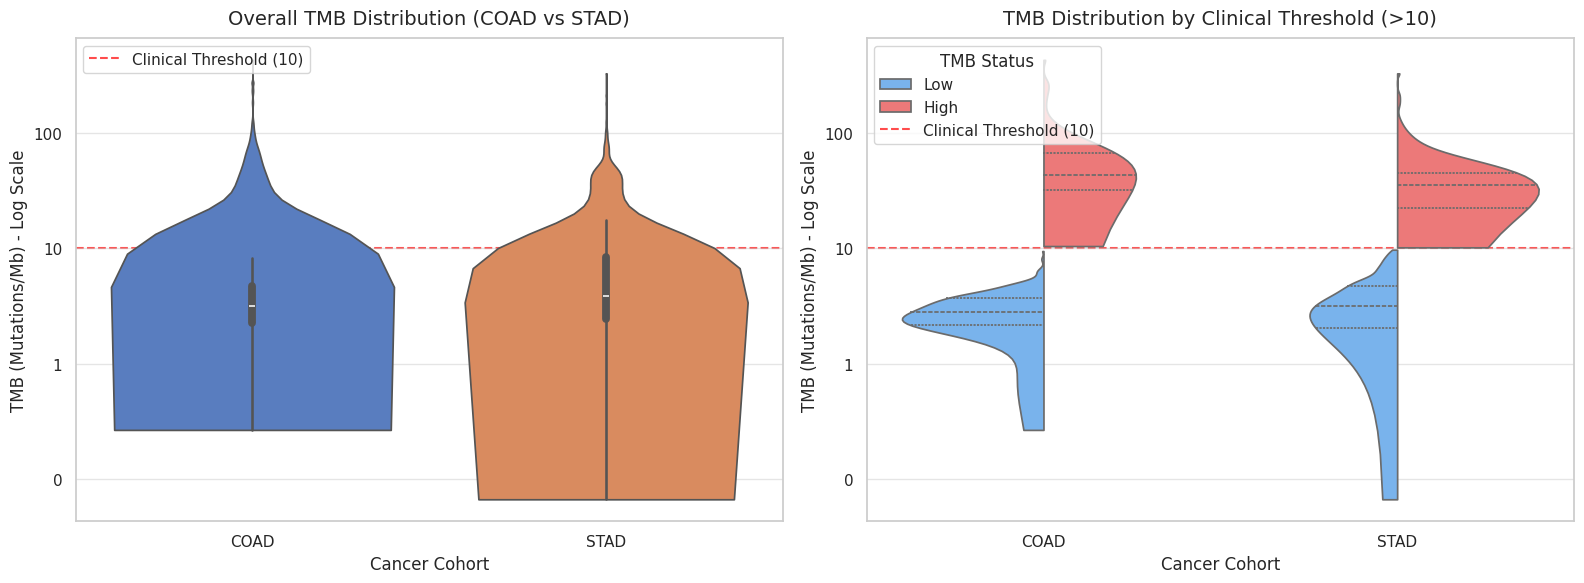

In [76]:
%matplotlib inline

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =====================================================================
# PLOT 1: Overall Distribution (No Label Split)
# =====================================================================
sns.violinplot(
    data=combined_df,
    x="Cohort",
    y="TMB_NONSYNONYMOUS",
    hue="Cohort",       # FIX: Satisfies the new Seaborn warning
    legend=False,       # FIX: Hides the redundant legend
    palette="muted",
    inner="box",
    cut=0,
    ax=axes[0]
)

axes[0].set_title("Overall TMB Distribution (COAD vs STAD)", fontsize=14, pad=10)
axes[0].set_ylabel("TMB (Mutations/Mb) - Log Scale", fontsize=12)
axes[0].set_xlabel("Cancer Cohort", fontsize=12)
axes[0].set_yscale("log")

# =====================================================================
# PLOT 2: Distribution Split by "High" vs "Low" Label
# =====================================================================
sns.violinplot(
    data=combined_df,
    x="Cohort",
    y="TMB_NONSYNONYMOUS",
    hue="TMB_Label",
    split=True,
    palette={"High": "#ff6666", "Low": "#66b3ff"},
    inner="quartile",
    cut=0,
    ax=axes[1]
)

axes[1].set_title("TMB Distribution by Clinical Threshold (>10)", fontsize=14, pad=10)
axes[1].set_ylabel("TMB (Mutations/Mb) - Log Scale", fontsize=12)
axes[1].set_xlabel("Cancer Cohort", fontsize=12)
axes[1].set_yscale("log")

# =====================================================================
# FORMATTING & AESTHETICS
# =====================================================================
for ax in axes:
    ax.axhline(10, color='red', linestyle='--', alpha=0.7, zorder=0, label='Clinical Threshold (10)')
    ax.yaxis.set_major_formatter(ScalarFormatter())

axes[0].legend(loc="upper left")
axes[1].legend(title="TMB Status", loc="upper left")

plt.tight_layout()
plt.show()